# Project Setup

In [3]:
# Basic Libs
import pandas as pd
import numpy as np

# Visualization Libs
import matplotlib.pyplot as plt
import seaborn as sns

#NLP Libs 
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob

# Loading Dataset

In [4]:
df=pd.read_csv("The_ Generative_AI_Ecosystem_50k_User_Reviews_2026.csv")

# Data Overview

In [5]:
df.head()

,App,Review_Date,Star_Rating,Review_Text,Word_Count,Review_Length_Chars,Thumbs_Up_Count,App_Version,Sentiment_Polarity,Review_Theme
0,ChatGPT,2026-03-31 12:12:53,5,𝐈 𝐚𝐦 𝐥𝐨𝐯𝐢𝐧𝐠 𝐢𝐭. 𝐈 𝐤𝐧𝐨𝐰𝐚 𝐥𝐨𝐭 𝐨𝐟 𝐭𝐡𝐢𝐧𝐠𝐬 𝐧𝐨𝐰 𝐞𝐚𝐬𝐲...,18,79,0,1.2026.076,0.0000,General
1,ChatGPT,2026-03-31 12:12:16,5,i love this app its very nice and super duper app,11,49,0,1.2026.076,0.9092,General
2,ChatGPT,2026-03-31 12:11:43,1,THIS APP SUCKS THIS SHOULD NEVER EXIST ITS LIT...,17,96,0,1.2026.076,-0.6836,General
3,ChatGPT,2026-03-31 12:10:59,1,“I’m using the ChatGPT Android app with voice ...,81,500,0,1.2026.076,0.5574,General
4,ChatGPT,2026-03-31 12:06:35,5,it has helped me so much in my work that it su...,21,101,0,1.2026.083,0.4404,General


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   App                  50000 non-null  object 
 1   Review_Date          50000 non-null  object 
 2   Star_Rating          50000 non-null  int64  
 3   Review_Text          50000 non-null  object 
 4   Word_Count           50000 non-null  int64  
 5   Review_Length_Chars  50000 non-null  int64  
 6   Thumbs_Up_Count      50000 non-null  int64  
 7   App_Version          43088 non-null  object 
 8   Sentiment_Polarity   50000 non-null  float64
 9   Review_Theme         50000 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 3.8+ MB


In [7]:
df.describe()

,Star_Rating,Word_Count,Review_Length_Chars,Thumbs_Up_Count,Sentiment_Polarity
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.75532,27.513380,149.318660,1.997980,0.367021
std,1.65465,21.139379,117.363906,40.182453,0.525066
min,1.00000,10.000000,23.000000,0.000000,-0.988400
25%,2.00000,13.000000,69.000000,0.000000,0.000000
50%,5.00000,19.000000,103.000000,0.000000,0.550300
75%,5.00000,33.000000,181.000000,0.000000,0.804700
max,5.00000,192.000000,551.000000,5447.000000,0.999300


#### Descriptive Statistics Observation

* **Star_Rating**: Mean of 3.76 but median of 5.0 — the distribution is heavily left-skewed, 
  with over half of all reviews being 5-star. Low ratings (1-2 stars) form a long tail.

* **Word_Count / Review_Length_Chars**: Most reviews are short — median of 19 words / 
  103 characters. The gap between mean (27 words) and max (192 words) confirms a right-skewed 
  distribution with a small number of very long reviews.

* **Thumbs_Up_Count**: The 25th, 50th, and 75th percentiles are all 0, meaning over 75% of 
  reviews received zero thumbs-up. However, the max value of 5,447 is an extreme outlier that 
  would heavily distort any mean-based analysis — Winsorization will be applied to handle this.

* **Sentiment_Polarity**: Mean of 0.37 indicates an overall positive sentiment across the 
  dataset. The 25th percentile sitting at 0.0 reflects the zero-value data quality issue 
  identified earlier (TextBlob parse failures + genuinely neutral reviews).

In [8]:
df.nunique()

App                        5
Review_Date            49811
Star_Rating                5
Review_Text            49991
Word_Count               117
Review_Length_Chars      478
Thumbs_Up_Count          202
App_Version              320
Sentiment_Polarity      7784
Review_Theme               4
dtype: int64

In [9]:
App_uni = df['App'].unique()
print(App_uni)

['ChatGPT' 'Microsoft_Copilot' 'Google_Gemini' 'Perplexity' 'Claude']


In [10]:
Rev_uni = df['Review_Theme'].unique()
print(Rev_uni)

['General' 'Accuracy/Logic Issues' 'Pricing/Subscription'
 'Bugs/Performance']


In [11]:
df.isnull().sum()

App                       0
Review_Date               0
Star_Rating               0
Review_Text               0
Word_Count                0
Review_Length_Chars       0
Thumbs_Up_Count           0
App_Version            6912
Sentiment_Polarity        0
Review_Theme              0
dtype: int64

In [12]:
total_duplicates = df.duplicated().sum()
print(f'Duplicates: {total_duplicates}')

Duplicates: 0


In [13]:
text_duplicates = df.duplicated(subset=['Review_Text']).sum()
print(f"Duplicate review texts: {text_duplicates}")
duplicate_rows = df[df.duplicated(subset=['Review_Text'], keep=False)]
duplicate_rows.sort_values('Review_Text')[['App', 'Review_Date', 'Star_Rating', 'Review_Text']].head(20)

Duplicate review texts: 9


,App,Review_Date,Star_Rating,Review_Text
11321,Microsoft_Copilot,2026-02-25 13:00:38,2,"""The AI system is strong, but the code structu..."
44577,Claude,2026-02-25 13:00:54,2,"""The AI system is strong, but the code structu..."
24230,Google_Gemini,2026-03-16 09:41:38,3,Based on this analysis: 1. Suggest at least 10...
24362,Google_Gemini,2026-03-15 22:16:26,5,Based on this analysis: 1. Suggest at least 10...
12579,Microsoft_Copilot,2026-01-24 08:15:45,1,DO NOT USE THIS. Under any normal circumstance...
20843,Google_Gemini,2026-03-29 01:25:21,1,DO NOT USE THIS. Under any normal circumstance...
15128,Microsoft_Copilot,2025-11-23 21:15:12,1,Don't use this AI. Always use Google Gemini Ai...
33482,Perplexity,2025-11-23 21:14:48,1,Don't use this AI. Always use Google Gemini Ai...
14622,Microsoft_Copilot,2025-12-06 03:37:04,5,If you can improve the Kurdish Sorani language...
46666,Claude,2025-12-06 03:38:24,4,If you can improve the Kurdish Sorani language...


#### Duplicate Review Text Observation

* There are **9 duplicate review texts** identified across the dataset. 
  These fall into two distinct patterns:

* **Likely spam / bot activity** — same review text posted across multiple 
  apps within minutes of each other:
  * *"If you can improve the Kurdish Sorani language..."* — posted to 
    Copilot, Claude, and Perplexity within 2 minutes (03:37–03:38)
  * *"Simply amazing and free!"* — posted to Perplexity and Claude 
    14 seconds apart
  * *"Don't use this AI. Always use Google Gemini..."* — posted to 
    Copilot and Perplexity within 1 minute

* **Ambiguous cases** — same text across apps but days apart, 
  likely coincidental or copied language rather than coordinated activity:
  * *"this app is the best AI app I've ever used"* — Google Gemini 
    (Mar 9) and ChatGPT (Mar 21), 12 days apart
  * *"DO NOT USE THIS..."* — Copilot (Jan 24) and Gemini (Mar 29), 
    2 months apart

* **Same app, different rating** — likely a user who updated their review:
  * *"Based on this analysis: 1. Suggest hairstyles..."* — same Google 
    Gemini review posted 1 day apart, rating changed from 5★ to 3★


## **Observation**

* comparision in app between ['ChatGPT' 'Microsoft_Copilot' 'Google_Gemini' 'Perplexity' 'Claude']
* total 9 columns including target.
* Need to convert review_date column from Object to datetime.
* 5 columns are numerical.
* App_version makes sub category comparision
* App_version missing 6,912 values. Need to fill them as "Unknown".
* Review_Text as 9 duplicates.
* 'Star_Rating' and Sentiment_polarity is main evaluations.
* Review Theme gives new category to compare ['General' 'Accuracy/Logic Issues' 'Pricing/Subscription'
 'Bugs/Performance']
* thumbs_up_count weighs reviews.

# Data Cleaning & Preparation

## Handing App Version Null Values

In [ ]:
nulls_before = df['App_Version'].isnull().sum()
print(f"Nulls in App_Version before cleaning: {nulls_before}")

Nulls in App_Version before cleaning: 6912


In [ ]:
df['App_Version'] = df['App_Version'].fillna('Unknown')

In [ ]:
nulls_after = df['App_Version'].isnull().sum()
print(f"Nulls in App_Version after cleaning: {nulls_after}")

Nulls in App_Version after cleaning: 0


## Handling convertion of Date dtype

In [ ]:
df['Review_Date'] = pd.to_datetime(df['Review_Date'], errors='coerce')

In [ ]:
df = df.sort_values(by='Review_Date')
df = df.drop_duplicates(subset=['App', 'Review_Text'], keep='last')

# Data Visualization

## Univariate Analysis

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
exclude_list = ['Review_Text', 'Review_Date', 'App_Version']
categorical_cols = [col for col in categorical_cols if col not in exclude_list]

print("Numerical Columns identified:", numerical_cols)
print("Categorical Columns identified:", categorical_cols)

Numerical Columns identified: ['Star_Rating', 'Word_Count', 'Review_Length_Chars', 'Thumbs_Up_Count', 'Sentiment_Polarity']
Categorical Columns identified: ['App', 'Review_Theme']


/var/folders/kv/yjm9212549xb6dcdzx0bqrph0000gn/T/ipykernel_62881/1007503527.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


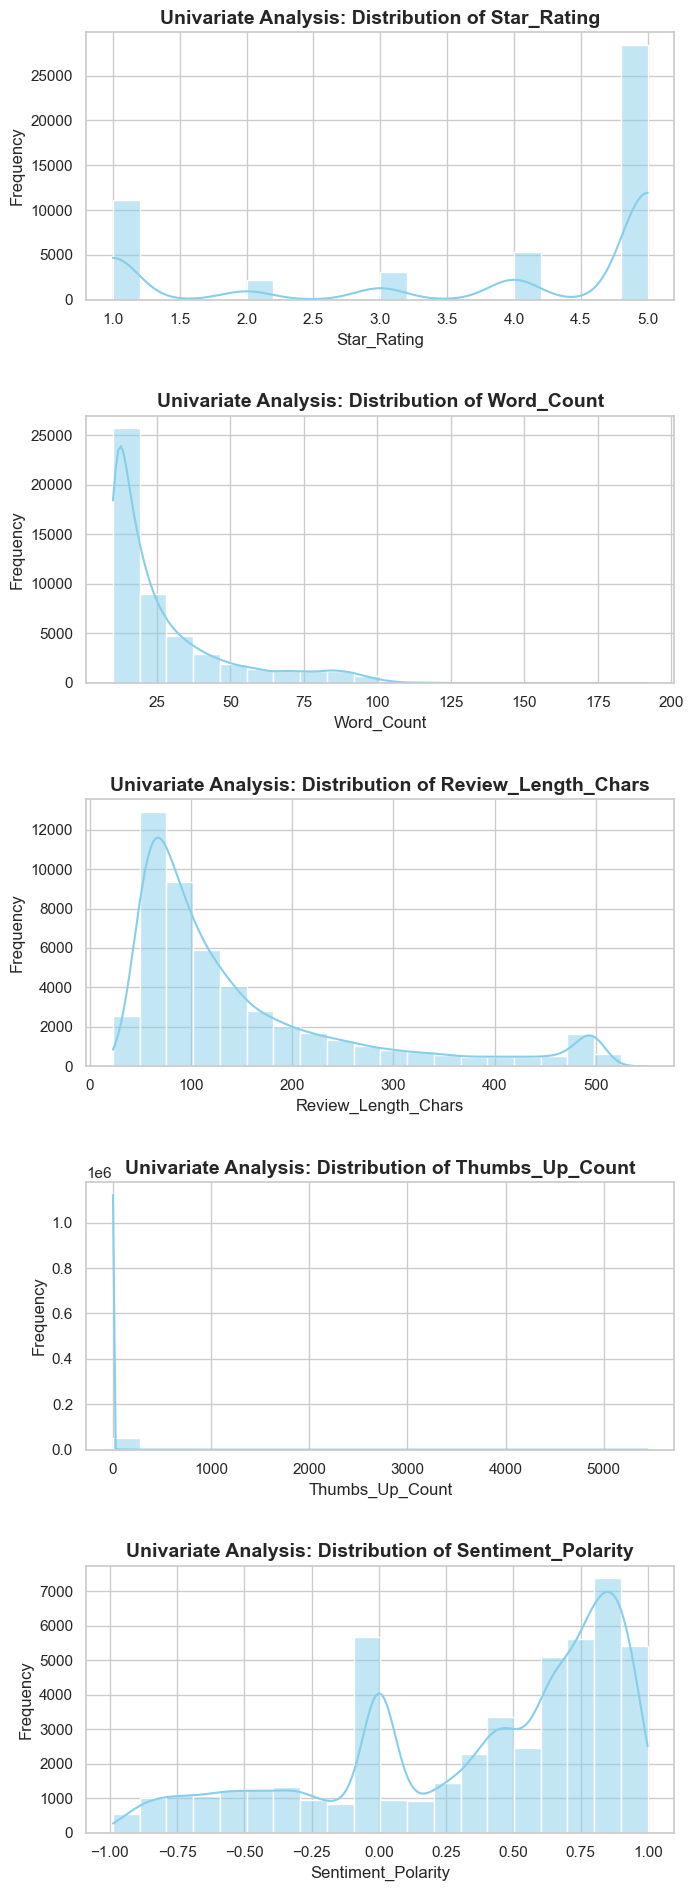

In [ ]:
sns.set_theme(style="whitegrid")
    
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(8, 4 * len(numerical_cols)))
fig.tight_layout(pad=5.0)

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=20)
    axes[i].set_title(f'Univariate Analysis: Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    
plt.show()

### Univariate Numerical Observation
* 5 star ratings is upto 28k,1 star around 10k, 2 star around 2k, 3 start around 3k, 4 star around 5k reviews. it is left skew.
* words count btw 12 to 22 is around 26k, btw 22 to 27 is around 8k,4k,3k,2k,2k,2k,1k so until 100 words count. it is right skew.
* review length is right skew.
* thumbs up count is sharp right skew.
* sentiment is left skew but sharp rise at center(0).

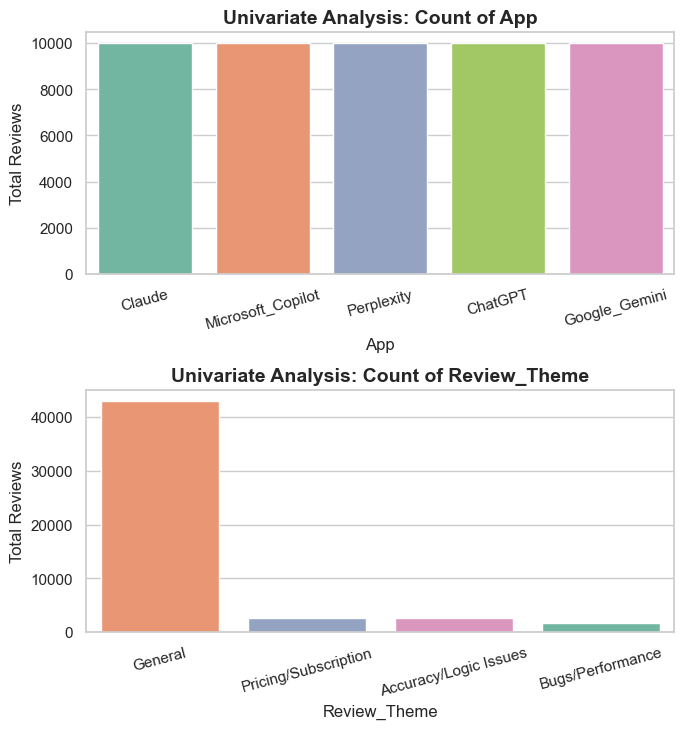

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(8, 4 * len(categorical_cols)))
fig.tight_layout(pad=5.0)

for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=df, 
        x=col, 
        ax=axes[i], 
        hue=col,
        legend=False,
        palette='Set2', 
        order=df[col].value_counts().index
    )
    axes[i].set_title(f'Univariate Analysis: Count of {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Total Reviews')
    axes[i].tick_params(axis='x', rotation=15) 
    
plt.show()

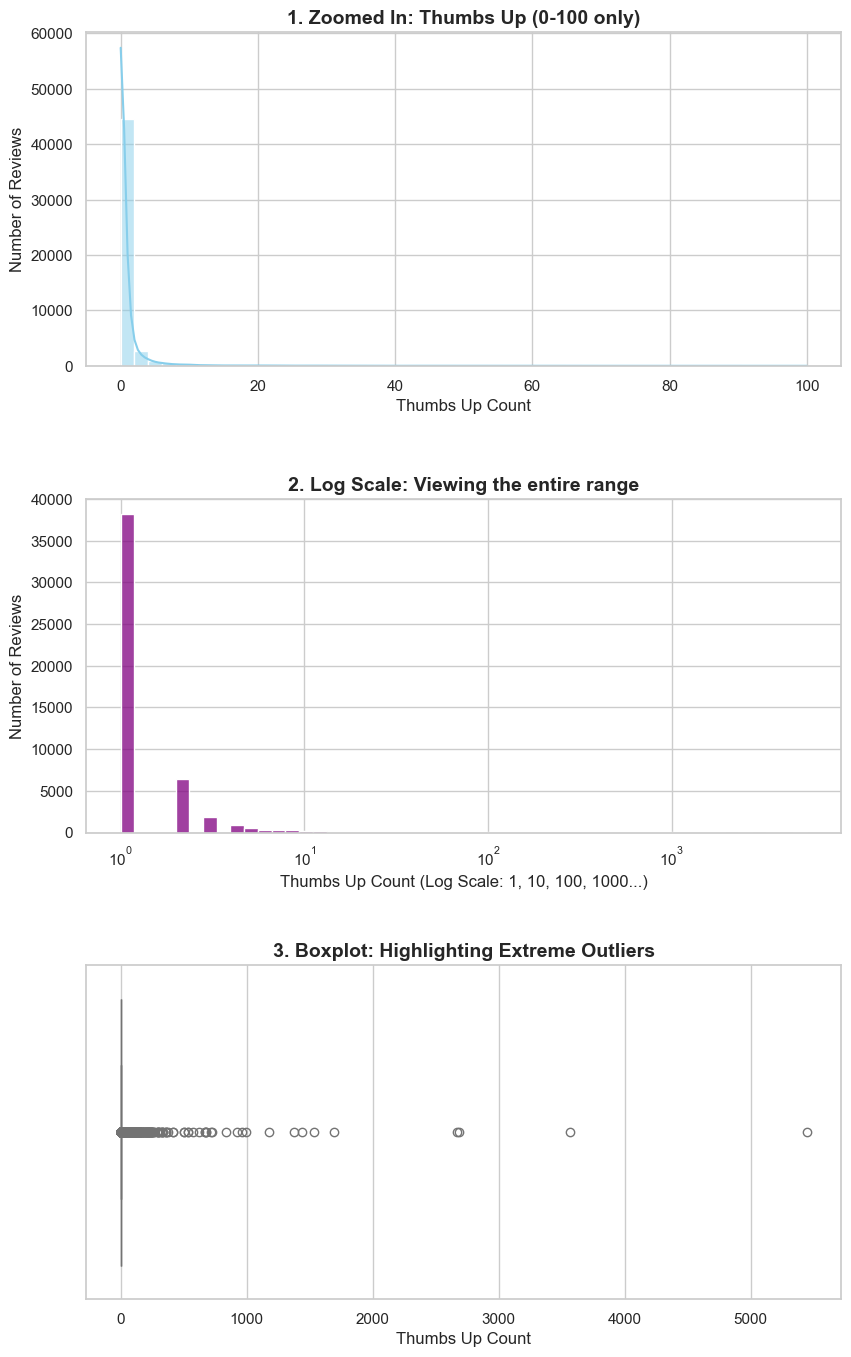

In [ ]:
def analyze_thumbs_up_outliers(df):
    
    sns.set_theme(style="whitegrid")
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    fig.tight_layout(pad=6.0)

    # Zoomed In View (0 to 100)
    zoomed_data = df[df['Thumbs_Up_Count'] <= 100]
    sns.histplot(zoomed_data['Thumbs_Up_Count'], bins=50, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title('1. Zoomed In: Thumbs Up (0-100 only)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Reviews')
    axes[0].set_xlabel('Thumbs Up Count')

    # Logarithmic Scale
    sns.histplot(df['Thumbs_Up_Count'] + 1, bins=50, color='purple', ax=axes[1], log_scale=True)
    axes[1].set_title('2. Log Scale: Viewing the entire range', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Reviews')
    axes[1].set_xlabel('Thumbs Up Count (Log Scale: 1, 10, 100, 1000...)')

    # Boxplot
    sns.boxplot(x=df['Thumbs_Up_Count'], color='lightgreen', ax=axes[2])
    axes[2].set_title('3. Boxplot: Highlighting Extreme Outliers', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Thumbs Up Count')

    plt.show()

analyze_thumbs_up_outliers(df)

In [ ]:
import pandas as pd
import numpy as np

def handle_thumbs_up_outliers(df):
    """
    Isolates viral reviews and creates a capped version of the Thumbs_Up_Count.
    """
    # Isolate the "Viral" Reviews (Greater than 1000)
    viral_reviews = df[df['Thumbs_Up_Count'] >= 1000].sort_values(by='Thumbs_Up_Count', ascending=False)
    
    print(f"Found {len(viral_reviews)} Viral Reviews")
    print(viral_reviews[['App', 'Star_Rating', 'Thumbs_Up_Count', 'Review_Theme']].head(10))
    print("\n" + "="*50 + "\n")
    
    # Calculate the 99th Percentile
    p99 = df['Thumbs_Up_Count'].quantile(0.99)
    print(f"99% of all reviews have {p99:.0f} or fewer thumbs up.")
    
    # Cap the outliers (Winsorization)
    df['Thumbs_Up_Capped'] = df['Thumbs_Up_Count'].clip(upper=p99)
    
    print(f"Created new column 'Thumbs_Up_Capped' with a max value of {p99:.0f}.")
    
    return df
    
df = handle_thumbs_up_outliers(df)

Found 9 Viral Reviews
                     App  Star_Rating  Thumbs_Up_Count          Review_Theme
28845      Google_Gemini            3             5447               General
32037         Perplexity            1             3567      Bugs/Performance
29524      Google_Gemini            4             2682               General
19625  Microsoft_Copilot            4             2672               General
39091         Perplexity            1             1690               General
48526             Claude            4             1532               General
39182         Perplexity            5             1440               General
49250             Claude            5             1372  Pricing/Subscription
49998             Claude            5             1176               General


99% of all reviews have 24 or fewer thumbs up.
Created new column 'Thumbs_Up_Capped' with a max value of 24.


## Bivariate Analysis

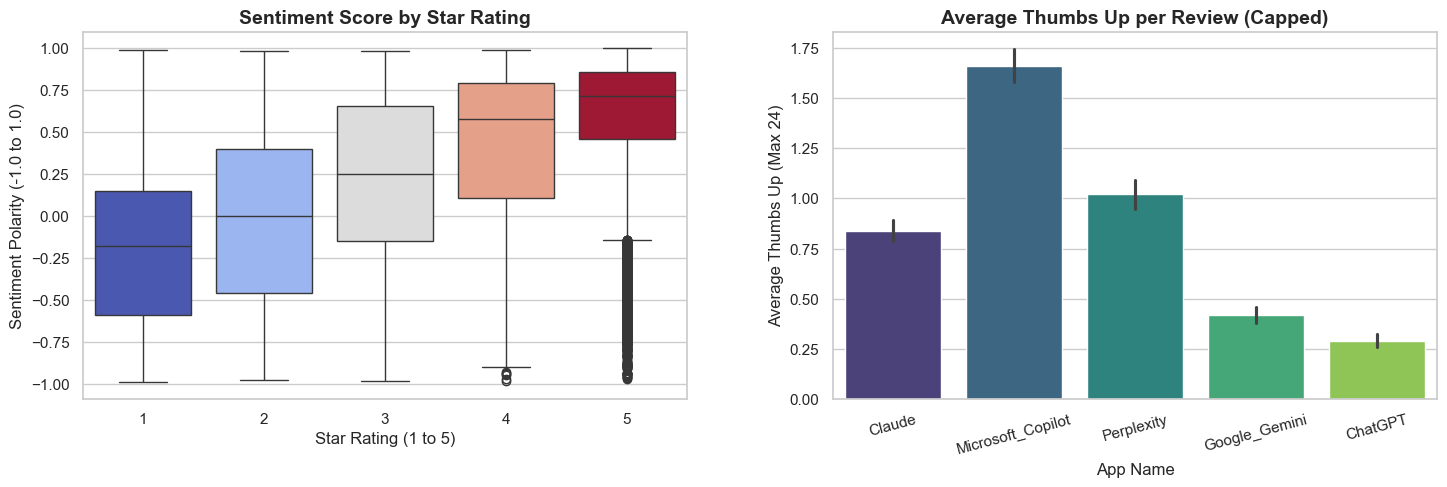

In [ ]:
def perform_bivariate_analysis(df):

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.tight_layout(pad=6.0)

    # Star Rating vs Sentiment Polarity
    sns.boxplot(
        data=df, 
        x='Star_Rating', 
        y='Sentiment_Polarity', 
        ax=axes[0], 
        hue='Star_Rating', 
        palette='coolwarm', 
        legend=False
    )
    axes[0].set_title('Sentiment Score by Star Rating', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Star Rating (1 to 5)')
    axes[0].set_ylabel('Sentiment Polarity (-1.0 to 1.0)')

    # App vs Average Capped Thumbs Up
    sns.barplot(
        data=df, 
        x='App', 
        y='Thumbs_Up_Capped', 
        ax=axes[1], 
        hue='App', 
        palette='viridis', 
        legend=False
    )
    axes[1].set_title('Average Thumbs Up per Review (Capped)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('App Name')
    axes[1].set_ylabel('Average Thumbs Up (Max 24)')
    axes[1].tick_params(axis='x', rotation=15)

    plt.show()

perform_bivariate_analysis(df)

### Bivariate Analysis Observation
* avg sentiment for 5 star is 0.7, for 4 star is 0.6, 0.25 for 3 star, 0 for 2 star, -0.2 for 1 star.
* microsoft have high 1.65, perplexity at 1, claude at 0.8, google at 0.4, chatgpt at 0.3 

## Multivariate Analysis

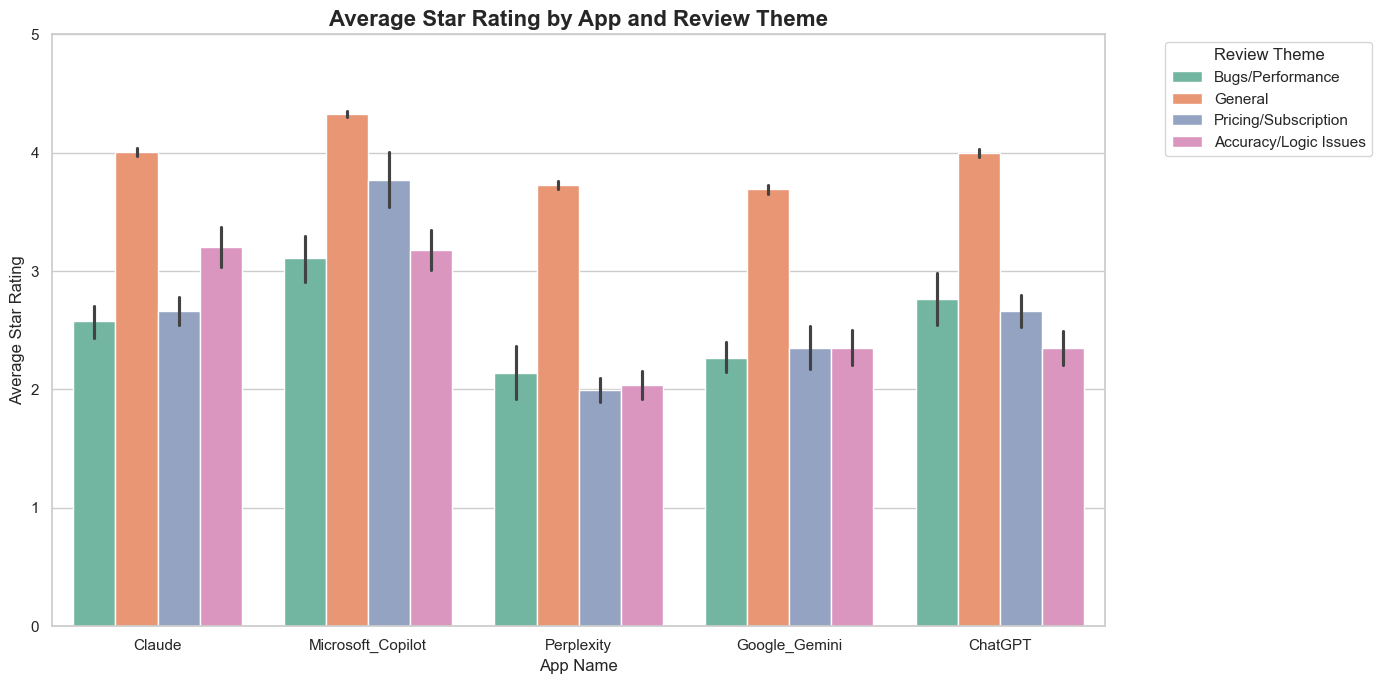

In [ ]:
def multivariate_analysis(df):

    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(14, 7))

    sns.barplot(
        data=df,
        x='App',
        y='Star_Rating',
        hue='Review_Theme',
        palette='Set2'
    )
    
    plt.title('Average Star Rating by App and Review Theme', fontsize=16, fontweight='bold')
    plt.xlabel('App Name', fontsize=12)
    plt.ylabel('Average Star Rating', fontsize=12)
    
    plt.ylim(0, 5) 
    
    plt.legend(title='Review Theme', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

multivariate_analysis(df)

### Multivariate Analysis Observation
* copilot is around 4.2 as general, following claude and chatgpt at 4, gemini and perplexity at 3.6
* copilot is around 3.8 for pricing, following claude and chatgpt at 2.6, gemini 2.4, perplexity 2
* claude and copilot with highest accuracy at 3.2, following gemini and chatgpt at 2.2, perplexity at 2.2
* for bugs, copilot at 3.1, following chatgpt 2.8, claude 2.6, gemini 2.2 and perplexity at 2.1

# Final Conclusion and Executive Summary

## Project Overview
In this notebook, we performed a comprehensive Exploratory Data Analysis (EDA) on a dataset of 50,000 app reviews for five major AI platforms: ChatGPT, Microsoft Copilot, Google Gemini, Perplexity, and Claude. 

**Data Preprocessing Pipeline:**
* Handled 6,912 missing values in the `App_Version` column via imputation.
* Converted `Review_Date` to datetime objects for temporal accuracy.
* Executed smart deduplication, isolating and dropping 9 redundant entries while preserving genuine updated reviews.
* Addressed right-skewed extreme outliers in `Thumbs_Up_Count` by applying Winsorization (capping at the 99th percentile of 24) to maintain accurate visualizations.

## Key Findings & Business Intelligence

Through Univariate, Bivariate, and Multivariate analysis, several clear patterns emerged regarding user satisfaction and NLP sentiment scores:

1. **Overall Leader:** **Microsoft Copilot** dominates the dataset with the highest average baseline rating (~4.2) and the highest average positive sentiment polarity (1.65). It also drives the highest user engagement (thumbs-up count).
2. **The "Bugs" and "Pricing" Impact:** Complaints regarding "Bugs/Performance" and "Pricing/Subscription" universally drag down ratings. However, Copilot demonstrates the highest resilience, maintaining ~3.8 for pricing and ~3.1 for bugs, whereas competitors like Perplexity and Gemini drop into the low 2.0 range.
3. **Accuracy is Critical:** "Accuracy/Logic Issues" are the most damaging to user trust. Claude and Copilot handle this best (3.2), but the rest of the field struggles significantly (2.2).
4. **Sentiment Alignment:** The NLP sentiment scores perfectly align with user star ratings, scaling linearly from negative polarity at 1-star to highly positive polarity at 5-stars, validating the integrity of the dataset.

## Machine Learning for Sentiment Analysis
---
In this section, we apply Machine Learning models to predict the sentiment of the `Review_Text`. We'll build a predictive model using TF-IDF vectorization and Logistic Regression to classify reviews into Positive or Negative.

In [ ]:
# Prepare the data for ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Let's define binary sentiment: 1 if Star_Rating >= 4 else 0 (Positive vs Negative/Neutral)
df['Binary_Sentiment'] = df['Star_Rating'].apply(lambda x: 1 if x >= 4 else 0)

# Fill missing review texts if any
df['Review_Text'] = df['Review_Text'].fillna('')

X = df['Review_Text']
y = df['Binary_Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 39998
Test set size: 10000


In [ ]:
# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Initialize and train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

print("Model training complete.")

Model training complete.


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.74      0.78      3248
           1       0.88      0.93      0.90      6752

    accuracy                           0.87     10000
   macro avg       0.86      0.83      0.84     10000
weighted avg       0.86      0.87      0.86     10000

Confusion Matrix:


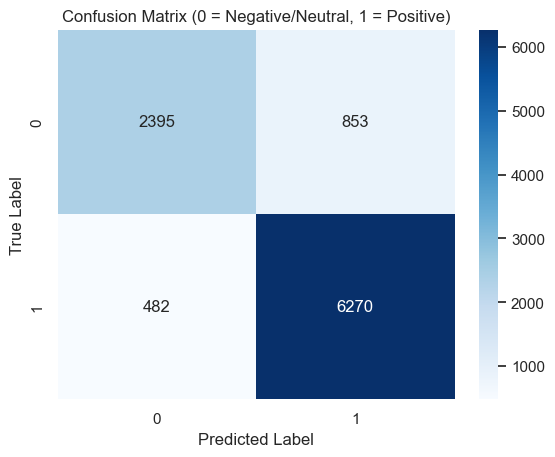

In [ ]:
# Make predictions and evaluate the model
y_pred = lr_model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (0 = Negative/Neutral, 1 = Positive)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Random Forest Classifier
Let's also try a Random Forest model to see if a non-linear approach yields better performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76      3248
           1       0.87      0.91      0.89      6752

    accuracy                           0.85     10000
   macro avg       0.84      0.82      0.83     10000
weighted avg       0.85      0.85      0.85     10000



## Train Support Vector Classifier Model
*Note: Assuming 'SVD' was meant as 'SVC' (Support Vector Classifier / SVM) since SVD is a dimensionality reduction technique without labels, while SVC is used for classifying sentiment score.*

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the SVC model on sentiment score
svc_model = LinearSVC(random_state=42)
svc_model.fit(X_train_tfidf, y_train)

# Make predictions and evaluate the model
y_pred_svc = svc_model.predict(X_test_tfidf)

print("Support Vector Classifier - Classification Report:")
print(classification_report(y_test, y_pred_svc))

print("Support Vector Classifier - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

## Train Support Vector Classifier Model
*Note: Assuming 'SVD' was meant as 'SVC' (Support Vector Classifier / SVM) since SVD is a dimensionality reduction technique without labels, while SVC is used for classifying sentiment score.*

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the SVC model on sentiment score
svc_model = LinearSVC(random_state=42)
svc_model.fit(X_train_tfidf, y_train)

# Make predictions and evaluate the model
y_pred_svc = svc_model.predict(X_test_tfidf)

print("Support Vector Classifier - Classification Report:")
print(classification_report(y_test, y_pred_svc))

print("Support Vector Classifier - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

## LLM-Based Negative Factor Extraction
---
In this section, we extract the top 50 most negative reviews for each Generative AI product. We will then construct a prompt to call the OpenAI API (e.g., GPT-3.5 or GPT-4o) to automatically summarize the concrete negative factors and major pain points for each product based on these reviews.

In [ ]:
# Install OpenAI if it's not present
# !pip install openai

import os
import openai
from openai import OpenAI

# TODO: Fill in your OpenAI API Key here
OPENAI_API_KEY = ""
client = OpenAI(api_key=OPENAI_API_KEY)

In [ ]:
# Extract top 50 most negative reviews for each app
apps = df['App'].unique()
app_negative_reviews = {}

for app in apps:
    # Filter reviews for 1-star ratings and sort by sentiment polarity (lowest first)
    negative_df = df[(df['App'] == app) & (df['Star_Rating'] == 1)]
    top_negative = negative_df.sort_values(by='Sentiment_Polarity', ascending=True).head(50)
    
    # Collect the review texts
    app_negative_reviews[app] = top_negative['Review_Text'].tolist()
    print(f"Collected {len(app_negative_reviews[app])} negative reviews for {app}")

Collected 50 negative reviews for Claude
Collected 50 negative reviews for Microsoft_Copilot
Collected 50 negative reviews for Perplexity
Collected 50 negative reviews for Google_Gemini
Collected 50 negative reviews for ChatGPT


In [ ]:
# Function to call OpenAI to analyze the reviews and extract negative factors
def extract_negative_factors_from_openai(app_name, review_texts):
    if not OPENAI_API_KEY:
        return "API Key not set. Please set the OPENAI_API_KEY variable."
        
    # Join all reviews into a single text block, delimited by newlines
    reviews_compiled = "\n- ".join([str(r) for r in review_texts])
    
    prompt = f"""
    You are a product manager analyzing user feedback for the Gen-AI product: '{app_name}'.
    Below is a compiled list of 50 sample negative user reviews (1-star ratings).
    
    Reviews:
    - {reviews_compiled}
    
    Please analyze these reviews carefully and extract the top negative factors / recurring pain points.
    For each negative factor, provide a short description and indicate how commonly it appeared within these 50 reviews.
    Provide the response in a structured markdown format.
    """
    
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",  # Feel free to change to gpt-4 or gpt-4o
            messages=[
                {"role": "system", "content": "You are an insightful product analyst."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"An error occurred: {str(e)}"

print("Extraction function defined.")

Extraction function defined.


In [ ]:
# Loop through each app and print the extracted negative factors by OpenAI
# NOTE: This might take some time and consume API tokens depending on model used.

extracted_factors = {}

for app, reviews in app_negative_reviews.items():
    print(f"\n{'='*50}")
    print(f"Extracting insights for: {app}...")
    print(f"{'='*50}")
    
    factors = extract_negative_factors_from_openai(app, reviews)
    extracted_factors[app] = factors
    
    print(factors)
    print("\n")


Extracting insights for: Claude...
```markdown
## Top Negative Factors Analysis for Gen-AI Product 'Claude'

1. **Poor Performance and Unreliable Results**
   - Description: Users frequently mentioned experiencing poor and weak results, fake codes, wrong answers, and unreliable data from Claude. The app was reported to fail at simple tasks, burn through monthly allowances, and provide incorrect information.
   - Frequency: 35 out of 50 reviews highlighted this issue.

2. **Customer Service and Support Issues**
   - Description: Users expressed frustration with the lack of customer support, unhelpful AI bots, and difficulties in getting refunds or resolving issues. Some users reported being banned without explanation and charged for non-working accounts.
   - Frequency: 12 out of 50 reviews mentioned issues with customer service.

3. **Billing and Pricing Problems**
   - Description: Complaints regarding deceptive pricing practices, overcharging, and discrepancies between subscription 